In [1]:
import numpy as np
import pandas as pd
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import warnings
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")
from itertools import product

In [2]:
"""
Geração de Base Sintética para Inferência Causal
=================================================
- Covariáveis qualitativas e quantitativas
- Tratamento binário com confounding (seleção não-aleatória)
- Efeito heterogêneo do tratamento (CATE varia por subgrupo)
- Potencial outcomes framework (Y0, Y1 observáveis para validação)
"""

np.random.seed(42)

# Gerando a base

In [3]:
# ── Parâmetros gerais ────────────────────────────────────────────────
N = 5_000  # observações
 
# ── 1. Covariáveis quantitativas ─────────────────────────────────────
idade = np.random.normal(loc=40, scale=12, size=N).clip(18, 75).round(1)
renda_mensal = np.random.lognormal(mean=8.5, sigma=0.6, size=N).round(2)  # em R$
score_credito = np.random.beta(a=5, b=2, size=N) * 900 + 100  # 100-1000
horas_estudo = np.random.exponential(scale=5, size=N).clip(0, 40).round(1)
 
# ── 2. Covariáveis qualitativas ──────────────────────────────────────
sexo = np.random.choice(["M", "F"], size=N, p=[0.48, 0.52])
regiao = np.random.choice(
    ["Sudeste", "Nordeste", "Sul", "Norte", "Centro-Oeste"],
    size=N,
    p=[0.42, 0.27, 0.15, 0.09, 0.07],
)
escolaridade = np.random.choice(
    ["Fundamental", "Medio", "Superior", "Pos-graduacao"],
    size=N,
    p=[0.15, 0.35, 0.35, 0.15],
)
plano_saude = np.random.choice(["Sim", "Nao"], size=N, p=[0.40, 0.60])
 
# ── 3. Propensity score (confounding intencional) ───────────────────
# Quem tem mais renda, mais escolaridade e é do Sudeste tem MAIOR
# probabilidade de receber o tratamento (programa de capacitação).
escol_num = np.where(
    escolaridade == "Fundamental", 0,
    np.where(escolaridade == "Medio", 1,
    np.where(escolaridade == "Superior", 2, 3))
)
regiao_sudeste = (regiao == "Sudeste").astype(float)
 
logit_ps = (
    -4.0
    + 0.03 * idade
    + 0.4 * np.log(renda_mensal + 1) / 2
    + 0.5 * escol_num
    + 0.3 * regiao_sudeste
    + 0.002 * score_credito
    - 0.05 * horas_estudo
)
propensity = 1 / (1 + np.exp(-logit_ps))
tratamento = np.random.binomial(1, propensity, size=N)
 
# ── 4. Efeito heterogêneo (CATE) ────────────────────────────────────
# O efeito do tratamento VARIA conforme:
#   - Idade: jovens se beneficiam mais
#   - Escolaridade: maior escolaridade → efeito menor (retornos decrescentes)
#   - Região Nordeste: efeito amplificado (maior margem de ganho)
#   - Sexo feminino: leve vantagem adicional
 
tau = (
    800                                          # efeito base
    - 10 * (idade - 30)                          # jovens ganham mais
    - 150 * escol_num                            # retornos decrescentes
    + 400 * (regiao == "Nordeste").astype(float)  # amplificação regional
    + 120 * (sexo == "F").astype(float)           # gap de gênero
    + 2.0 * horas_estudo                         # complementaridade
)
 
# ── 5. Potential outcomes ────────────────────────────────────────────
epsilon = np.random.normal(0, 300, size=N)
 
Y0 = (
    2000
    + 15 * idade
    + 0.1 * renda_mensal
    + 100 * escol_num
    + 50 * regiao_sudeste
    + 0.5 * score_credito
    + epsilon
)
 
Y1 = Y0 + tau
 
# Outcome observado (switching equation)
Y_obs = np.where(tratamento == 1, Y1, Y0).round(2)
 
# ── 6. Montar DataFrame ─────────────────────────────────────────────
df = pd.DataFrame({
    # Covariáveis quantitativas
    "idade": idade,
    "renda_mensal": renda_mensal,
    "score_credito": score_credito.round(1),
    "horas_estudo": horas_estudo,
    # Covariáveis qualitativas
    "sexo": sexo,
    "regiao": regiao,
    "escolaridade": escolaridade,
    "plano_saude": plano_saude,
    # Tratamento e outcome
    "tratamento": tratamento,
    "Y_obs": Y_obs,
    # Ground truth (para validação — remover antes de modelar)
    "_propensity_true": propensity.round(4),
    "_tau_true": tau.round(2),
    "_Y0": Y0.round(2),
    "_Y1": Y1.round(2),
})

In [4]:
df.head()

,idade,renda_mensal,score_credito,horas_estudo,sexo,regiao,escolaridade,plano_saude,tratamento,Y_obs,_propensity_true,_tau_true,_Y0,_Y1
0,46.0,3811.37,748.0,4.6,M,Sudeste,Pos-graduacao,Nao,1,3951.34,0.8904,199.2,3752.14,3951.34
1,38.3,3744.16,692.4,12.4,M,Nordeste,Superior,Nao,1,4892.56,0.6363,841.8,4050.76,4892.56
2,47.8,1673.40,905.0,3.6,M,Sul,Superior,Sim,1,3890.04,0.8247,329.2,3560.84,3890.04
3,58.3,4031.71,727.2,0.0,M,Norte,Superior,Sim,1,4304.82,0.8657,217.0,4087.82,4304.82
4,37.2,7628.89,815.6,1.2,M,Nordeste,Medio,Sim,0,3946.30,0.7262,980.4,3946.30,4926.70


In [5]:
df['tratamento'].value_counts()

tratamento
1    3569
0    1431
Name: count, dtype: int64

In [6]:
# Remover colunas de referencia do efeito verdadeiro
df.drop(columns=['_propensity_true','_tau_true','_Y0','_Y1'], inplace=True)

# Propensity score

In [7]:
# ── 1. Preparar ───────────────────────────────────────────
quali = ["sexo", "regiao", "escolaridade", "plano_saude"]
df_model = pd.get_dummies(df, columns=quali, drop_first=True)
 
X_cols = [c for c in df_model.columns if c not in ["tratamento", "Y_obs"]]
X = df_model[X_cols]
T = df_model["tratamento"]
Y = df_model["Y_obs"]

In [8]:
# ── 2. Propensity Score (Logística) ─────────────────────────────────
# Padronizar TODAS as features para coeficientes comparáveis
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X_cols)
 
lr = LogisticRegression(penalty=None,max_iter=5000, solver="lbfgs")
lr.fit(X_scaled, T)
ps = lr.predict_proba(X_scaled)[:, 1]
df["ps"] = ps
 
# ── 3. Diagnóstico ──────────────────────────────────────────────────
auc = roc_auc_score(T, ps)
 
print("=" * 55)
print("DIAGNÓSTICO DO PROPENSITY SCORE")
print("=" * 55)
print(f"\nAUC-ROC: {auc:.4f}")
print(f"\n  Interpretação para PS:")
print(f"  0.50–0.60 → confounding fraco (quase experimento)")
print(f"  0.60–0.75 → confounding moderado, boa sobreposição ✓")
print(f"  0.75–0.85 → confounding forte, atenção ao suporte")
print(f"  > 0.85    → grupos muito separados, inferência frágil")

DIAGNÓSTICO DO PROPENSITY SCORE

AUC-ROC: 0.6928

  Interpretação para PS:
  0.50–0.60 → confounding fraco (quase experimento)
  0.60–0.75 → confounding moderado, boa sobreposição ✓
  0.75–0.85 → confounding forte, atenção ao suporte
  > 0.85    → grupos muito separados, inferência frágil


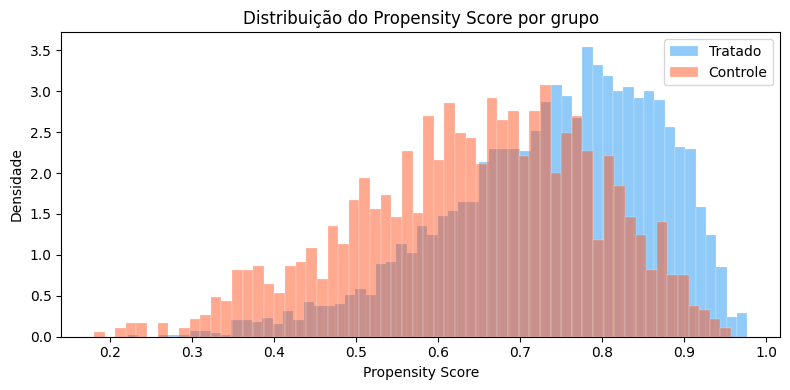

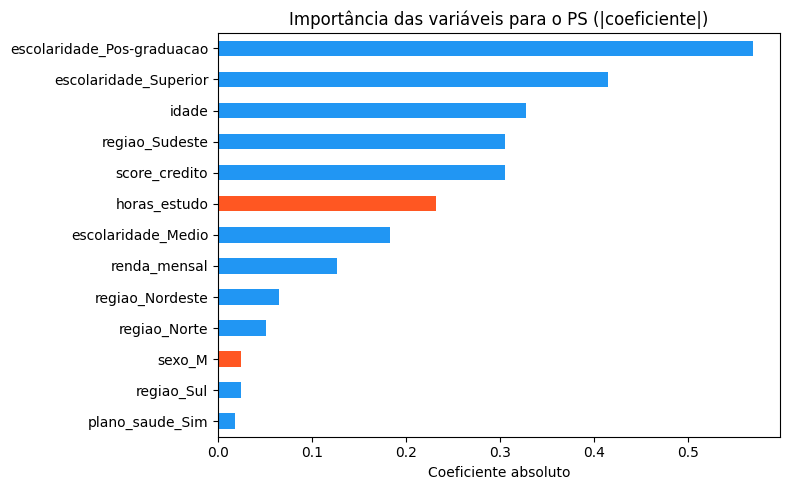

In [9]:
# ── 4. GRÁFICO 1: Distribuição do PS por grupo ──────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ps[T == 1], bins=60, alpha=0.5, color="#2196F3",
        label="Tratado", density=True, edgecolor="white", linewidth=0.3)
ax.hist(ps[T == 0], bins=60, alpha=0.5, color="#FF5722",
        label="Controle", density=True, edgecolor="white", linewidth=0.3)
ax.set_title("Distribuição do Propensity Score por grupo")
ax.set_xlabel("Propensity Score")
ax.set_ylabel("Densidade")
ax.legend()
plt.tight_layout()
plt.show()
plt.close()
 
# ── 5. GRÁFICO 2: Importância das variáveis ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
coef_df = (pd.DataFrame({"var": X_cols, "coef": np.abs(lr.coef_[0])})
           .sort_values("coef", ascending=True))
colors = ["#2196F3" if c > 0 else "#FF5722"
          for c in lr.coef_[0][coef_df.index]]
coef_df.plot.barh(x="var", y="coef", ax=ax, legend=False, color=colors)
ax.set_title("Importância das variáveis para o PS (|coeficiente|)")
ax.set_xlabel("Coeficiente absoluto")
ax.set_ylabel("")
plt.tight_layout()
plt.show()
plt.close()

In [10]:
# ── 6. Suporte Comum (em vez de trimming arbitrário) ────────────────
# Região onde AMBOS os grupos têm observações
ps_min_tratado  = ps[T == 1].min()
ps_max_tratado  = ps[T == 1].max()
ps_min_controle = ps[T == 0].min()
ps_max_controle = ps[T == 0].max()
 
# Suporte comum = interseção dos ranges
cs_lower = max(ps_min_tratado, ps_min_controle)
cs_upper = min(ps_max_tratado, ps_max_controle)
 
mask = (ps >= cs_lower) & (ps <= cs_upper)
n_antes = len(df)
n_depois = mask.sum()
n_removido = n_antes - n_depois
df = df.loc[mask].copy().reset_index(drop=True)
 
print("=" * 55)
print("SUPORTE COMUM (Common Support)")
print("=" * 55)
print(f"\n  Range tratado:  [{ps_min_tratado:.4f}, {ps_max_tratado:.4f}]")
print(f"  Range controle: [{ps_min_controle:.4f}, {ps_max_controle:.4f}]")
print(f"  Suporte comum:  [{cs_lower:.4f}, {cs_upper:.4f}]")
print(f"\n  Antes:    {n_antes:,} obs")
print(f"  Removido: {n_removido:,} obs ({n_removido/n_antes:.1%})")
print(f"  Depois:   {n_depois:,} obs")
print(f"    Tratados: {(T[mask]==1).sum():,}")
print(f"    Controle: {(T[mask]==0).sum():,}")

SUPORTE COMUM (Common Support)

  Range tratado:  [0.2224, 0.9769]
  Range controle: [0.1807, 0.9571]
  Suporte comum:  [0.2224, 0.9571]

  Antes:    5,000 obs
  Removido: 23 obs (0.5%)
  Depois:   4,977 obs
    Tratados: 3,550
    Controle: 1,427


# Matching

In [11]:
df.head()

,idade,renda_mensal,score_credito,horas_estudo,sexo,regiao,escolaridade,plano_saude,tratamento,Y_obs,ps
0,46.0,3811.37,748.0,4.6,M,Sudeste,Pos-graduacao,Nao,1,3951.34,0.908247
1,38.3,3744.16,692.4,12.4,M,Nordeste,Superior,Nao,1,4892.56,0.598968
2,47.8,1673.40,905.0,3.6,M,Sul,Superior,Sim,1,3890.04,0.807815
3,58.3,4031.71,727.2,0.0,M,Norte,Superior,Sim,1,4304.82,0.845789
4,37.2,7628.89,815.6,1.2,M,Nordeste,Medio,Sim,0,3946.30,0.699712


In [12]:
quali = ["sexo", "regiao", "escolaridade", "plano_saude"]
quanti = ["idade", "renda_mensal", "score_credito", "horas_estudo"]
 
df_enc = pd.get_dummies(df, columns=quali, drop_first=True)
X_cols = [c for c in df_enc.columns if c not in ["tratamento", "Y_obs", "ps"]]
 
T = df["tratamento"].values
Y = df["Y_obs"].values
ps = df["ps"].values
 
idx_t = np.where(T == 1)[0]
idx_c = np.where(T == 0)[0]

# Transformar PS para escala logit para o matching.
# O caliper no logit é mais estável que no PS cru,
# especialmente nas caudas.
logit_ps = np.log(ps / (1 - ps))

In [13]:
def run_matching(ps, idx_t, idx_c, k=1, caliper=None, replace=True,
                 max_use=None, exact_col=None, df=None):
    """
    Nearest-neighbor matching no PS (ou logit do PS).
    Pede k*20 candidatos ao KDTree e para quando acumula k aceitos,
    garantindo que filtros de caliper/max_use/replace não reduzam
    o número efetivo de controles por tratado.
    Retorna lista de (idx_tratado, [idx_controles_matched]).
    """
    pairs = []
    use_count = np.zeros(len(ps), dtype=int)

    if exact_col is not None and df is not None:
        strata = df[exact_col].values
        groups = np.unique(strata)
    else:
        groups = [None]
        strata = None

    for g in groups:
        if strata is not None:
            it = idx_t[strata[idx_t] == g]
            ic = idx_c[strata[idx_c] == g]
        else:
            it, ic = idx_t, idx_c

        if len(ic) == 0:
            continue

        # Quando replace=False, aleatorizar a ordem dos tratados
        # para que nenhum tratado tenha prioridade sistemática
        # sobre os melhores controles (matching guloso).
        # Com reposição isso não faz diferença.
        if not replace:
            rng_order = np.random.default_rng(42)
            it = rng_order.permutation(it)

        tree = KDTree(ps[ic].reshape(-1, 1))

        for i in it:
            # Pedir k*20 candidatos (margem ampla para filtros).
            # Muito mais que k, mas sem pedir todos (que seria O(n)).
            n_candidates = min(len(ic), k * 20)
            dist, pos = tree.query(ps[i].reshape(1, -1), k=n_candidates)
            dist = np.atleast_1d(dist.flatten())
            pos = np.atleast_1d(pos.flatten())

            matched = []
            for d, p in zip(dist, pos):
                if len(matched) >= k:
                    break

                c_idx = ic[p]

                if caliper is not None and d > caliper:
                    break    # ordenado por distância — os próximos são piores

                if not replace and use_count[c_idx] >= 1:
                    continue

                if max_use is not None and use_count[c_idx] >= max_use:
                    continue

                matched.append(c_idx)
                use_count[c_idx] += 1

            if matched:
                pairs.append((i, matched))

    return pairs, use_count


# ── 3. Função de métricas (com pesos) ───────────────────────────────
def calc_metrics(pairs, use_count, X_enc, T):
    if len(pairs) == 0:
        return None

    # Construir vetores de índices e pesos
    t_indices = []
    t_weights = []
    c_indices = []
    c_weights = []

    for t_idx, c_list in pairs:
        t_indices.append(t_idx)
        t_weights.append(1.0)

        k_i = len(c_list)
        for c_idx in c_list:
            c_indices.append(c_idx)
            c_weights.append(1.0 / k_i)

    t_indices = np.array(t_indices)
    t_weights = np.array(t_weights)
    c_indices = np.array(c_indices)
    c_weights = np.array(c_weights)

    # SMD ponderado por covariável
    X_t = X_enc[t_indices].astype(float)
    X_c = X_enc[c_indices].astype(float)

    mean_t = np.average(X_t, axis=0, weights=t_weights)
    mean_c = np.average(X_c, axis=0, weights=c_weights)

    var_t = np.average((X_t - mean_t) ** 2, axis=0, weights=t_weights)
    var_c = np.average((X_c - mean_c) ** 2, axis=0, weights=c_weights)

    std_pool = np.sqrt((var_t + var_c) / 2)
    std_pool = np.where(std_pool == 0, 1, std_pool)
    smd = np.abs((mean_t - mean_c) / std_pool)

    # Cobertura
    n_tratados_total = (T == 1).sum()
    n_controle_total = (T == 0).sum()
    controles_unicos = np.sum(use_count[T == 0] > 0)

    # ESS com peso efetivo (não contagem bruta).
    # Cada controle acumula 1/k_i por cada par onde aparece.
    peso_efetivo = np.zeros(len(T))
    for t_idx, c_list in pairs:
        k_i = len(c_list)
        for c_idx in c_list:
            peso_efetivo[c_idx] += 1.0 / k_i

    w = peso_efetivo[T == 0]
    w = w[w > 0]
    ess = (w.sum() ** 2) / (w ** 2).sum() if len(w) > 0 else 0

    return {
        "pct_smd_ok": (smd < 0.1).mean() * 100,
        "smd_max": smd.max(),
        "smd_medio": smd.mean(),
        "pct_tratados_usados": len(t_indices) / n_tratados_total * 100,
        "pct_controles_usados": controles_unicos / n_controle_total * 100,
        "ess_controle": round(ess, 1),
        "n_pares": len(pairs),
    }

In [14]:
# ── 4. Definir grid ─────────────────────────────────────────────────
logit_std = logit_ps.std()

grid = {
    "k":        [1, 3, 5],
    "replace":  [True, False],
    "caliper":  [None, round(0.2 * logit_std, 4), round(0.1 * logit_std, 4)],
    "exact":    [None, "sexo", "regiao"],
    "max_use":  [None, 5, 10],       # só relevante com reposição
}
 
X_enc = df_enc[X_cols].values.astype(float)
 
# ── 5. Rodar grid ───────────────────────────────────────────────────
results = []
combos = list(product(grid["k"], grid["replace"], grid["caliper"],
                       grid["exact"], grid["max_use"]))
 
# Filtrar combinações inválidas
valid = []
for k, rep, cal, ex, mx in combos:
    # max_use só faz sentido com reposição
    if not rep and mx is not None:
        continue
    # com reposição, sempre ter um max_use (None = ilimitado, testar só None)
    if rep and mx is None:
        # manter None = sem limite
        pass
    valid.append((k, rep, cal, ex, mx))
 
print(f"Testando {len(valid)} configurações...\n")
 
for i, (k, rep, cal, ex, mx) in enumerate(valid):
    pairs, use_count = run_matching(
        logit_ps, idx_t, idx_c,
        k=k, caliper=cal, replace=rep,
        max_use=mx, exact_col=ex, df=df
    )
    m = calc_metrics(pairs, use_count, X_enc, T)
    if m is None:
        continue
 
    m.update({
        "k": k,
        "reposicao": rep,
        "caliper": cal if cal else "Sem",
        "exact_var": ex if ex else "Nenhuma",
        "max_uso_controle": mx if mx else "Ilimitado",
    })
    results.append(m)
 
    if (i + 1) % 20 == 0:
        print(f"  {i+1}/{len(valid)} concluídas...")
 
# ── 6. Montar ranking ───────────────────────────────────────────────
df_res = pd.DataFrame(results)
 
# Reordenar colunas: config primeiro, métricas depois
config_cols = ["k", "reposicao", "caliper", "exact_var", "max_uso_controle"]
metric_cols = ["pct_smd_ok", "smd_max", "smd_medio",
               "pct_tratados_usados", "pct_controles_usados",
               "ess_controle", "n_pares"]
df_res = df_res[config_cols + metric_cols].reset_index(drop=True)

Testando 108 configurações...

  20/108 concluídas...
  40/108 concluídas...
  60/108 concluídas...
  80/108 concluídas...
  100/108 concluídas...


In [15]:
df_res.head()

,k,reposicao,caliper,exact_var,max_uso_controle,pct_smd_ok,smd_max,smd_medio,pct_tratados_usados,pct_controles_usados,ess_controle,n_pares
0,1,True,Sem,Nenhuma,Ilimitado,100.0,0.074298,0.026478,100.000000,72.529783,513.3,3550
1,1,True,Sem,Nenhuma,5,100.0,0.036812,0.013922,90.309859,74.982481,813.2,3206
2,1,True,Sem,Nenhuma,10,100.0,0.040930,0.021288,99.126761,72.810091,623.5,3519
3,1,True,Sem,sexo,Ilimitado,100.0,0.082877,0.023706,100.000000,72.319552,523.0,3550
4,1,True,Sem,sexo,5,100.0,0.054870,0.020293,90.478873,74.491941,818.9,3212


In [16]:
print(f"""
{'='*65}
COMO AVALIAR CADA MÉTRICA
{'='*65}
 
pct_smd_ok (% covariáveis com SMD < 0.1)
  → Mede quantas covariáveis ficaram balanceadas após o matching.
  → Ideal: 100%. Aceitável: > 80%.
  → É a métrica mais importante. Se não houver balanço, o efeito
    causal estimado será enviesado.
 
smd_max (maior SMD entre todas as covariáveis)
  → Mostra o pior caso de desbalanceamento.
  → Ideal: < 0.10. Tolerável: < 0.25.
  → Mesmo com pct_smd_ok alto, um smd_max grande indica que
    uma covariável específica ficou mal pareada.
 
smd_medio (média dos SMDs)
  → Visão geral do balanceamento.
  → Ideal: < 0.05. Complementa o smd_max, que pode ser puxado
    por uma única variável.
 
pct_tratados_usados (% de tratados que foram pareados)
  → Mede a representatividade. Se for baixo, o ATT estimado
    vale só para um subgrupo dos tratados.
  → Ideal: o mais alto possível sem sacrificar o balanço.
 
pct_controles_usados (% de controles únicos utilizados)
  → Com reposição, alguns controles são usados várias vezes
    enquanto outros ficam de fora. Quanto maior, melhor.
  → Ideal: > 80%.
 
ess_controle (Effective Sample Size do grupo controle)
  → N "real" descontando reutilização de controles.
  → Se ESS << n_controles, há alta dependência de poucos controles.
  → Quanto maior, menor a variância do estimador.
 
n_pares (número de pares formados)
  → Volume bruto de pares. Com K > 1 ou reposição, pode ser
    maior que o número de controles disponíveis.
  → Usar junto com ESS para interpretar a potência real.
""")


COMO AVALIAR CADA MÉTRICA
 
pct_smd_ok (% covariáveis com SMD < 0.1)
  → Mede quantas covariáveis ficaram balanceadas após o matching.
  → Ideal: 100%. Aceitável: > 80%.
  → É a métrica mais importante. Se não houver balanço, o efeito
    causal estimado será enviesado.
 
smd_max (maior SMD entre todas as covariáveis)
  → Mostra o pior caso de desbalanceamento.
  → Ideal: < 0.10. Tolerável: < 0.25.
  → Mesmo com pct_smd_ok alto, um smd_max grande indica que
    uma covariável específica ficou mal pareada.
 
smd_medio (média dos SMDs)
  → Visão geral do balanceamento.
  → Ideal: < 0.05. Complementa o smd_max, que pode ser puxado
    por uma única variável.
 
pct_tratados_usados (% de tratados que foram pareados)
  → Mede a representatividade. Se for baixo, o ATT estimado
    vale só para um subgrupo dos tratados.
  → Ideal: o mais alto possível sem sacrificar o balanço.
 
pct_controles_usados (% de controles únicos utilizados)
  → Com reposição, alguns controles são usados várias vezes

In [17]:
# ══════════════════════════════════════════════════════════════════════
# CONFIGURAÇÃO — ALTERE AQUI CONFORME SUA ESCOLHA DO GRID
# ══════════════════════════════════════════════════════════════════════
K           = 3        # número de vizinhos
REPLACE     = True     # com reposição
ps_std = df["ps"].std()
CALIPER     = round(0.2 * logit_std, 4)   # caliper no logit do PS (0.2 desvios), None se for sem caliper
EXACT_VAR   = "sexo"   # None, "sexo" ou "regiao"
MAX_USE     = 10       # None = ilimitado (só relevante se REPLACE=True)
# ══════════════════════════════════════════════════════════════════════

In [18]:
T = df["tratamento"].values
ps = df["ps"].values
logit_ps = np.log(ps / (1 - ps))
idx_t = np.where(T == 1)[0]
idx_c = np.where(T == 0)[0]

# Usar logit_ps no matching (a função run_matching já está definida na cell 15)
pairs, use_count = run_matching(
    logit_ps, idx_t, idx_c,
    k=K,
    caliper=CALIPER,
    replace=REPLACE,
    max_use=MAX_USE,
    exact_col=EXACT_VAR,
    df=df,
)

print(f"{'='*55}")
print(f"MATCHING EXECUTADO")
print(f"{'='*55}")
print(f"  Config: K={K}, reposição={REPLACE}, caliper={CALIPER},")
print(f"          exact={EXACT_VAR}, max_uso={MAX_USE}")
print(f"  Pares formados: {len(pairs):,}")
print(f"  Tratados pareados: {len(pairs):,} / {len(idx_t):,}")
print(f"  Controles únicos usados: {(use_count[idx_c] > 0).sum()} / {len(idx_c)}")

MATCHING EXECUTADO
  Config: K=3, reposição=True, caliper=0.1482,
          exact=sexo, max_uso=10
  Pares formados: 2,944
  Tratados pareados: 2,944 / 3,550
  Controles únicos usados: 1359 / 1427


In [19]:
# ── 3. BASE 1: Expandida (controles repetidos, com match_id) ────────
rows = []
for match_id, (t_idx, c_list) in enumerate(pairs):
    # Linha do tratado
    row_t = df.iloc[t_idx].to_dict()
    row_t["match_id"] = match_id
    row_t["match_role"] = "tratado"
    rows.append(row_t)
 
    # Linhas dos controles (cada aparição é uma linha)
    for c_idx in c_list:
        row_c = df.iloc[c_idx].to_dict()
        row_c["match_id"] = match_id
        row_c["match_role"] = "controle"
        rows.append(row_c)
 
df_expanded = pd.DataFrame(rows)
 
# ── 4. BASE 2: Ponderada (sem repetição, com peso para WLS) ─────────
# Tratados: peso = 1 (cada um aparece uma vez)
# Controles: peso proporcional ao número de vezes que foi usado,
#            normalizado para que a soma dos pesos controle = soma dos pesos tratados.
#            Isso garante que tratados e controles tenham influência igual na WLS.
 
t_matched_idx = [p[0] for p in pairs]
c_all_idx = [c for p in pairs for c in p[1]]
 
# Contar vezes que cada controle foi usado
c_counts = pd.Series(c_all_idx).value_counts()
 
# Base de tratados
df_t = df.iloc[t_matched_idx].copy()
df_t["peso"] = 1.0
 
# Base de controles (únicos)
c_unique_idx = c_counts.index.tolist()
df_c = df.iloc[c_unique_idx].copy()
raw_weights = c_counts.loc[c_unique_idx].values.astype(float)
 
# Normalizar: soma dos pesos controle = número de tratados
df_c["peso"] = raw_weights * (len(t_matched_idx) / raw_weights.sum())
 
df_weighted = pd.concat([df_t, df_c], ignore_index=True)

In [20]:
df_expanded.head()

,idade,renda_mensal,score_credito,horas_estudo,sexo,regiao,escolaridade,plano_saude,tratamento,Y_obs,ps,match_id,match_role
0,37.2,2288.06,447.6,12.8,F,Sudeste,Fundamental,Nao,1,3788.21,0.359754,0,tratado
1,25.1,3916.10,550.2,10.2,F,Norte,Medio,Nao,0,3359.10,0.360106,0,controle
2,20.3,3156.94,704.5,3.4,F,Sul,Fundamental,Nao,0,3017.87,0.360109,0,controle
3,39.7,2823.02,696.6,17.1,F,Nordeste,Fundamental,Sim,0,3516.45,0.358904,0,controle
4,49.2,6585.76,814.1,2.5,F,Sul,Medio,Sim,1,4543.29,0.741913,1,tratado


In [21]:
df_expanded['tratamento'].value_counts()

tratamento
0    8737
1    2944
Name: count, dtype: int64

In [22]:
df_weighted.head()

,idade,renda_mensal,score_credito,horas_estudo,sexo,regiao,escolaridade,plano_saude,tratamento,Y_obs,ps,peso
0,37.2,2288.06,447.6,12.8,F,Sudeste,Fundamental,Nao,1,3788.21,0.359754,1.0
1,49.2,6585.76,814.1,2.5,F,Sul,Medio,Sim,1,4543.29,0.741913,1.0
2,34.4,3163.58,590.2,7.8,F,Sudeste,Pos-graduacao,Sim,1,3706.99,0.822841,1.0
3,46.5,4514.65,861.7,9.1,F,Sudeste,Pos-graduacao,Nao,1,4259.47,0.917864,1.0
4,34.4,12822.97,781.6,3.2,F,Nordeste,Medio,Nao,1,5849.76,0.685213,1.0


# Avaliacao SMD

In [23]:
# ══════════════════════════════════════════════════════════════════════
# CONFIGURAÇÃO
# ══════════════════════════════════════════════════════════════════════
QUALI = ["sexo", "regiao", "escolaridade", "plano_saude"]
QUANTI = ["idade", "renda_mensal", "score_credito", "horas_estudo"]
# ══════════════════════════════════════════════════════════════════════

In [24]:
df_pre = df.copy()
df_pos = df_expanded.copy()

# Pesos pós-matching: tratado=1, controle=1/K
n_ctrl = df_pos.groupby("match_id")["match_role"].transform(lambda x: (x == "controle").sum())
df_pos["peso"] = np.where(df_pos["match_role"] == "tratado", 1.0, 1.0 / n_ctrl)
 
# Dummies
df_pre_enc = pd.get_dummies(df_pre, columns=QUALI, drop_first=False)
df_pos_enc = pd.get_dummies(df_pos, columns=QUALI, drop_first=False)
# Alinhar colunas: adicionar com zero as que faltam em uma das bases
df_pre_enc, df_pos_enc = df_pre_enc.align(df_pos_enc, join="outer", axis=1, fill_value=0)
 
# Todas as variáveis numéricas para diagnóstico
all_vars = QUANTI + [c for c in df_pre_enc.columns
                     if any(c.startswith(q + "_") for q in QUALI)]
 
T_pre = df_pre["tratamento"].values
T_pos = df_pos["tratamento"].values
W_pos = df_pos["peso"].values

In [25]:
# ── 2. Funções de métricas ───────────────────────────────────────────
def smd(x_t, x_c, w_t=None, w_c=None):
    """Standardized Mean Difference."""
    m_t = np.average(x_t, weights=w_t)
    m_c = np.average(x_c, weights=w_c)
    v_t = np.average((x_t - m_t) ** 2, weights=w_t)
    v_c = np.average((x_c - m_c) ** 2, weights=w_c)
    pooled = np.sqrt((v_t + v_c) / 2)
    return (m_t - m_c) / pooled if pooled > 0 else 0.0
 
 
def var_ratio(x_t, x_c, w_t=None, w_c=None):
    """Razão de variâncias (tratado / controle). Ideal ~ 1."""
    m_t = np.average(x_t, weights=w_t)
    m_c = np.average(x_c, weights=w_c)
    v_t = np.average((x_t - m_t) ** 2, weights=w_t)
    v_c = np.average((x_c - m_c) ** 2, weights=w_c)
    return v_t / v_c if v_c > 0 else np.nan
 
 
def ks_stat(x_t, x_c):
    """Kolmogorov-Smirnov statistic (máx. diferença entre ECDFs)."""
    from scipy.stats import ks_2samp
    return ks_2samp(x_t, x_c).statistic

In [26]:
# ── 3. Calcular métricas pré e pós ──────────────────────────────────
rows = []
for var in all_vars:
    x_pre = df_pre_enc[var].values.astype(float)
    x_pos = df_pos_enc[var].values.astype(float)
 
    # Pré (sem pesos)
    xt_pre = x_pre[T_pre == 1]
    xc_pre = x_pre[T_pre == 0]
 
    smd_pre = smd(xt_pre, xc_pre)
    vr_pre = var_ratio(xt_pre, xc_pre)
    ks_pre = ks_stat(xt_pre, xc_pre)
 
    # Pós (com pesos do matching)
    xt_pos = x_pos[T_pos == 1]
    xc_pos = x_pos[T_pos == 0]
    wt_pos = W_pos[T_pos == 1]
    wc_pos = W_pos[T_pos == 0]
 
    smd_pos = smd(xt_pos, xc_pos, wt_pos, wc_pos)
    vr_pos = var_ratio(xt_pos, xc_pos, wt_pos, wc_pos)
    ks_pos = ks_stat(xt_pos, xc_pos)
 
    # Melhora
    pct_melhora_smd = (1 - abs(smd_pos) / abs(smd_pre)) * 100 if abs(smd_pre) > 0.001 else np.nan
 
    rows.append({
        "variavel": var,
        "smd_pre": smd_pre,
        "smd_pos": smd_pos,
        "abs_smd_pre": abs(smd_pre),
        "abs_smd_pos": abs(smd_pos),
        "pct_reducao_smd": pct_melhora_smd,
        "var_ratio_pre": vr_pre,
        "var_ratio_pos": vr_pos,
        "ks_pre": ks_pre,
        "ks_pos": ks_pos,
    })
 
df_diag = pd.DataFrame(rows).sort_values("abs_smd_pre", ascending=False)

In [27]:
# ── 4. Resumo no console ────────────────────────────────────────────
print("=" * 85)
print("DIAGNÓSTICO DE BALANCEAMENTO — PRÉ vs PÓS MATCHING")
print("=" * 85)
 
print(f"\n  Base pré:  {len(df_pre):,} obs (T={T_pre.sum():,} | C={(1-T_pre).sum():,})")
print(f"  Base pós:  {len(df_pos):,} obs (T={T_pos.sum():,} | C={(1-T_pos).sum():,})")
 
print(f"\n{'─'*85}")
print("TABELA COMPLETA")
print(f"{'─'*85}\n")
 
cols_print = ["variavel", "smd_pre", "smd_pos", "pct_reducao_smd",
              "var_ratio_pre", "var_ratio_pos", "ks_pre", "ks_pos"]
with pd.option_context("display.float_format", "{:.4f}".format, "display.width", 130):
    print(df_diag[cols_print].to_string(index=False))
 
# Resumo de limiares
n_vars = len(all_vars)
print(f"\n{'─'*85}")
print("RESUMO DE LIMIARES")
print(f"{'─'*85}")
print(f"\n  SMD (|SMD| < 0.1 = balanceado):")
print(f"    Pré:  {(df_diag['abs_smd_pre'] < 0.1).sum()}/{n_vars} balanceadas")
print(f"    Pós:  {(df_diag['abs_smd_pos'] < 0.1).sum()}/{n_vars} balanceadas")
 
print(f"\n  Variance Ratio (0.5 < VR < 2.0 = aceitável):")
ok_vr_pre = ((df_diag["var_ratio_pre"] > 0.5) & (df_diag["var_ratio_pre"] < 2.0)).sum()
ok_vr_pos = ((df_diag["var_ratio_pos"] > 0.5) & (df_diag["var_ratio_pos"] < 2.0)).sum()
print(f"    Pré:  {ok_vr_pre}/{n_vars} aceitáveis")
print(f"    Pós:  {ok_vr_pos}/{n_vars} aceitáveis")
 
print(f"\n  KS statistic (< 0.1 = boa sobreposição):")
print(f"    Pré:  {(df_diag['ks_pre'] < 0.1).sum()}/{n_vars} OK")
print(f"    Pós:  {(df_diag['ks_pos'] < 0.1).sum()}/{n_vars} OK")
 
print(f"\n{'─'*85}")
print("COMO INTERPRETAR CADA MÉTRICA")
print(f"{'─'*85}")
print("""
  SMD (Standardized Mean Difference)
    Diferença de médias entre tratado e controle em unidades de desvio-padrão.
    |SMD| < 0.1 → balanceado.  |SMD| > 0.25 → desbalanceamento relevante.
 
  pct_reducao_smd
    Quanto o matching reduziu o |SMD| em relação ao pré.
    > 0% → melhorou.  Negativo → piorou.
 
  Variance Ratio (tratado / controle)
    Compara a dispersão das distribuições.  Ideal = 1.0.
    Aceitável entre 0.5 e 2.0.  Fora disso → distribuições com formas diferentes.
 
  KS statistic (Kolmogorov-Smirnov)
    Máxima distância entre as distribuições acumuladas.
    < 0.1 → distribuições muito próximas.
    > 0.2 → diferença relevante na forma da distribuição.
""")

DIAGNÓSTICO DE BALANCEAMENTO — PRÉ vs PÓS MATCHING

  Base pré:  4,977 obs (T=3,550 | C=1,427)
  Base pós:  11,681 obs (T=2,944 | C=8,737)

─────────────────────────────────────────────────────────────────────────────────────
TABELA COMPLETA
─────────────────────────────────────────────────────────────────────────────────────

                  variavel  smd_pre  smd_pos  pct_reducao_smd  var_ratio_pre  var_ratio_pos  ks_pre  ks_pos
escolaridade_Pos-graduacao   0.3189   0.0023          99.2885         2.1280         1.0053  0.1050  0.0073
                     idade   0.2800  -0.0012          99.5561         1.0182         0.9760  0.1162  0.0153
             score_credito   0.2764   0.0229          91.7205         0.8233         0.9650  0.1111  0.0229
  escolaridade_Fundamental  -0.2561  -0.0054          97.8946         0.6192         0.9888  0.0939  0.0033
            regiao_Sudeste   0.2194  -0.0305          86.0859         1.0853         0.9914  0.1072  0.0136
              horas_est

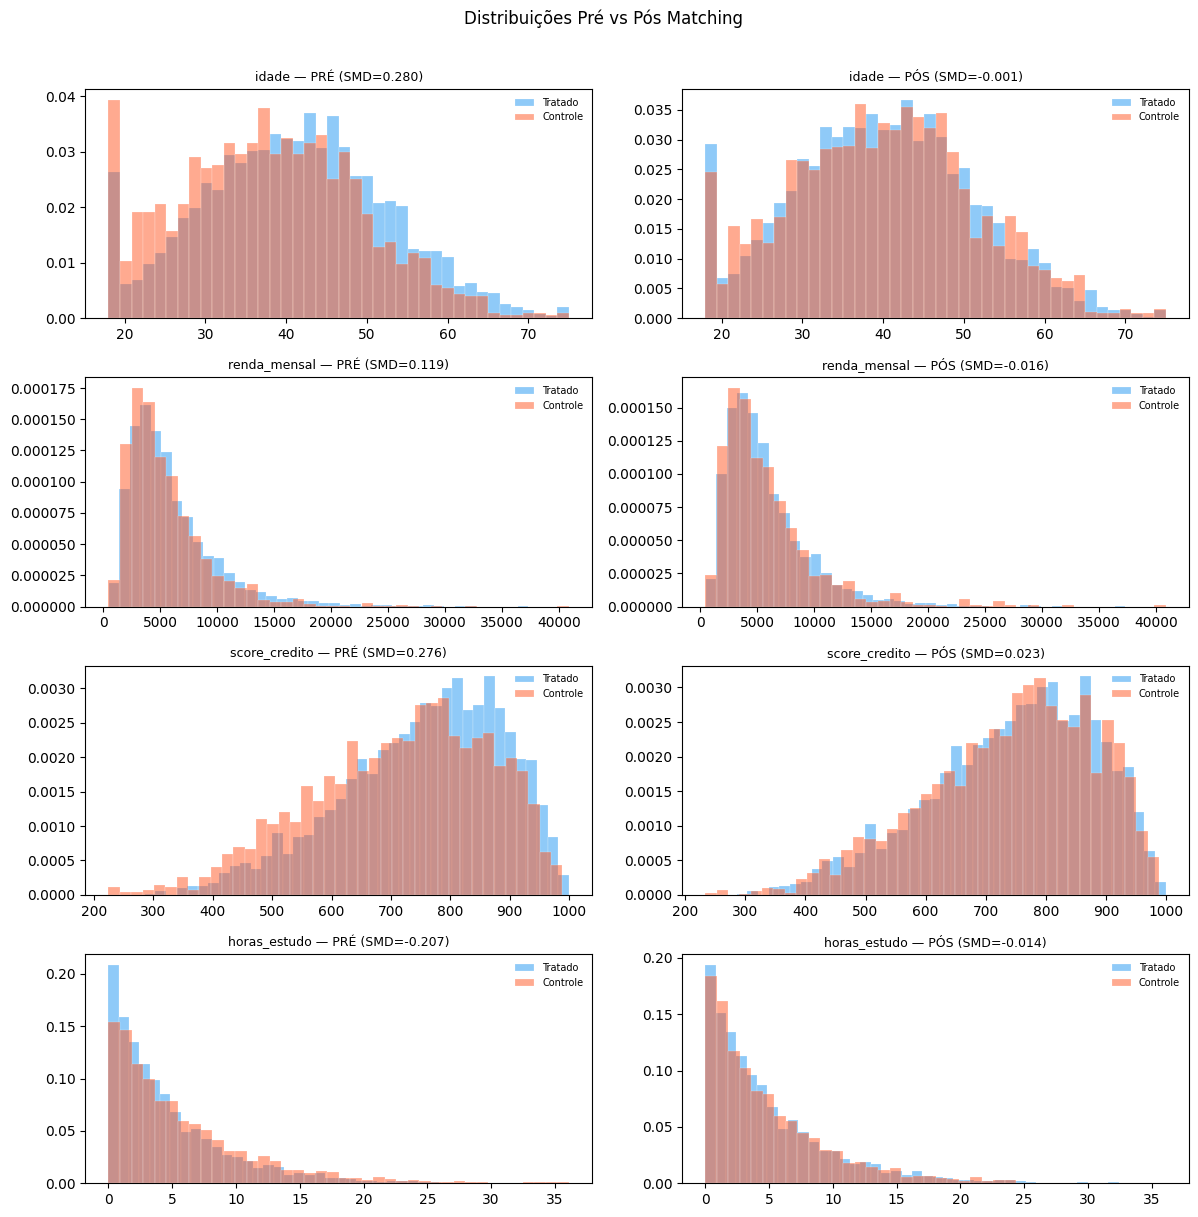

In [28]:
# 5. Distribuições das quantitativas (pré vs pós, lado a lado)
fig, axes = plt.subplots(len(QUANTI), 2, figsize=(12, 3 * len(QUANTI)))
for i, var in enumerate(QUANTI):
    # ── Pré (sem pesos, como antes) ─────────────────────────────────
    ax = axes[i, 0]
    ax.hist(df_pre_enc.loc[T_pre == 1, var], bins=40, alpha=0.5, color="#2196F3",
            label="Tratado", density=True, edgecolor="white", linewidth=0.3)
    ax.hist(df_pre_enc.loc[T_pre == 0, var], bins=40, alpha=0.5, color="#FF5722",
            label="Controle", density=True, edgecolor="white", linewidth=0.3)
    smd_val = df_diag.loc[df_diag["variavel"] == var, "smd_pre"].values[0]
    ax.set_title(f"{var} — PRÉ (SMD={smd_val:.3f})", fontsize=9)
    ax.legend(fontsize=7, frameon=False)

    # ── Pós (com pesos do matching) ─────────────────────────────────
    ax = axes[i, 1]
    ax.hist(df_pos_enc.loc[T_pos == 1, var], bins=40, alpha=0.5, color="#2196F3",
            label="Tratado", density=True, edgecolor="white", linewidth=0.3,
            weights=W_pos[T_pos == 1])                # ← peso dos tratados
    ax.hist(df_pos_enc.loc[T_pos == 0, var], bins=40, alpha=0.5, color="#FF5722",
            label="Controle", density=True, edgecolor="white", linewidth=0.3,
            weights=W_pos[T_pos == 0])                # ← peso dos controles
    smd_val = df_diag.loc[df_diag["variavel"] == var, "smd_pos"].values[0]
    ax.set_title(f"{var} — PÓS (SMD={smd_val:.3f})", fontsize=9)
    ax.legend(fontsize=7, frameon=False)

plt.suptitle("Distribuições Pré vs Pós Matching", fontsize=12, y=1.01)
plt.tight_layout()

# WLS

In [29]:
import statsmodels.formula.api as smf

In [30]:
# ══════════════════════════════════════════════════════════════════════
# CONFIGURAÇÃO
# ══════════════════════════════════════════════════════════════════════
 
REFERENCIA = {
    "sexo":          "F",
    "regiao":        "Sudeste",
    "escolaridade":  "Superior",
    "plano_saude":   "Sim",
}
 
# Variáveis no modelo base
QUANTI = [
    "idade",
    "renda_mensal",
    "score_credito",
    "horas_estudo"
]
 
QUALI = [
    "sexo",
    "regiao",
    "escolaridade",
    "plano_saude",
]
 
# Cada item gera um modelo separado: base + essa interação
INTERACOES = [
    "tratamento:idade",
    "tratamento:C(regiao)",
    "tratamento:C(escolaridade)",
]
 
# ══════════════════════════════════════════════════════════════════════

In [31]:
for col, ref in REFERENCIA.items():
    if col in QUALI:
        cats = sorted(df_expanded[col].unique())
        df_expanded[col] = pd.Categorical(
            df_expanded[col], categories=[ref] + [c for c in cats if c != ref]
        )
 
# Pesos: tratado = 1, controles = 1/K
n_controles = df_expanded.groupby("match_id")["match_role"].apply(
    lambda x: (x == "controle").sum()
)
if "k_match" in df_expanded.columns:
    df_expanded = df_expanded.drop(columns=["k_match"])
df_expanded = df_expanded.merge(n_controles.rename("k_match"), on="match_id")
df_expanded["peso"] = df_expanded.apply(
    lambda r: 1.0 if r["match_role"] == "tratado" else 1.0 / r["k_match"], axis=1
)
 
# ── 2. Fórmula base ─────────────────────────────────────────────────
termos_base = ["tratamento"] + QUANTI + [f"C({c})" for c in QUALI]
formula_base = "Y_obs ~ " + " + ".join(termos_base)
 
# ── 3. Função para ajustar e imprimir ────────────────────────────────
def fit_model(formula, label):
    model = smf.wls(formula, data=df_expanded, weights=df_expanded["peso"]).fit(
        cov_type="cluster",
        cov_kwds={"groups": df_expanded["match_id"]}
    )
    print(f"\n{'='*70}")
    print(f"MODELO: {label}")
    print(f"{'='*70}")
    print(f"Fórmula: {formula}")
    print(model.summary())
 
    ci = model.conf_int().loc["tratamento"]
    print(f"\nATT = {model.params['tratamento']:.2f}  "
          f"IC95% = [{ci[0]:.2f}, {ci[1]:.2f}]  "
          f"p = {model.pvalues['tratamento']:.6f}")
 
    # Mostrar CATEs se houver interação
    cates = [v for v in model.params.index if "tratamento:" in v]
    if cates:
        print(f"\nCATEs (desvio em relação ao ATT base):")
        for var in cates:
            coef = model.params[var]
            p = model.pvalues[var]
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
            print(f"  {var:45s}  {coef:>+10.2f}  p={p:.4f} {sig}")
 
    return model

In [32]:
# ── 4. Rodar modelos ────────────────────────────────────────────────
# Modelo base
fit_model(formula_base, "BASE (sem interação)")
 
# Um modelo por interação
for inter in INTERACOES:
    formula_inter = formula_base + " + " + inter
    fit_model(formula_inter, f"CATE: {inter}")


MODELO: BASE (sem interação)
Fórmula: Y_obs ~ tratamento + idade + renda_mensal + score_credito + horas_estudo + C(sexo) + C(regiao) + C(escolaridade) + C(plano_saude)
                            WLS Regression Results                            
Dep. Variable:                  Y_obs   R-squared:                       0.739
Model:                            WLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     1646.
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        02:06:16   Log-Likelihood:                -84895.
No. Observations:               11681   AIC:                         1.698e+05
Df Residuals:                   11666   BIC:                         1.699e+05
Df Model:                          14                                         
Covariance Type:              cluster                                         
                                       co

# Bootstrap

In [33]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

In [34]:
for col, ref in REFERENCIA.items():
    if col in QUALI:
        cats = sorted(df_expanded[col].unique())
        df_expanded[col] = pd.Categorical(
            df_expanded[col], categories=[ref] + [c for c in cats if c != ref]
        )
 
match_ids = df_expanded["match_id"].unique()
n_matches = len(match_ids)
match_groups = {mid: df_expanded[df_expanded["match_id"] == mid] for mid in match_ids}

In [35]:
# ══════════════════════════════════════════════════════════════════════
# CONFIGURAÇÃO
# ══════════════════════════════════════════════════════════════════════
N_BOOT = 10
SEED = 42
 
REFERENCIA = {
    "sexo":          "F",
    "regiao":        "Sudeste",
    "escolaridade":  "Superior",
    "plano_saude":   "Sim",
}
 
QUALI = ["sexo", "regiao", "escolaridade","plano_saude"]
QUANTI = ["idade", "renda_mensal", "score_credito","horas_estudo"]
 
PERCENTIS = [2.5, 5, 25, 50, 75, 95, 97.5]

In [36]:
# ── 2. Bootstrap ─────────────────────────────────────────────────────
FORMULA = ("Y_obs ~ tratamento + idade + renda_mensal + score_credito + horas_estudo "
           "+ C(sexo) + C(regiao) + C(escolaridade) + C(plano_saude)")

rng = np.random.default_rng(SEED)
coefs_list = []
 
for b in range(N_BOOT):
    boot_ids = rng.choice(match_ids, size=n_matches, replace=True)
    df_boot = pd.concat([match_groups[mid] for mid in boot_ids], ignore_index=True)
 
    # Recalcular pesos
    block_id = np.repeat(np.arange(n_matches),
                         [len(match_groups[mid]) for mid in boot_ids])
    df_boot["_block"] = block_id
    n_ctrl = df_boot.groupby("_block")["match_role"].transform(
        lambda x: (x == "controle").sum()
    )
    df_boot["peso"] = np.where(df_boot["match_role"] == "tratado", 1.0, 1.0 / n_ctrl)
 
    for col, ref in REFERENCIA.items():
        if col in QUALI:
            cats = sorted(df_expanded[col].unique())
            df_boot[col] = pd.Categorical(
                df_boot[col], categories=[ref] + [c for c in cats if c != ref]
            )
 
    try:
        model = smf.wls(FORMULA, data=df_boot, weights=df_boot["peso"]).fit(disp=0)
        coefs_list.append(model.params)
    except Exception:
        continue
 
# ── 3. Tabela de percentis ───────────────────────────────────────────
df_coefs = pd.DataFrame(coefs_list)
resultado = df_coefs.quantile([p / 100 for p in PERCENTIS]).T
resultado.columns = [f"p{p}" for p in PERCENTIS]
 
print(resultado.round(2).to_string())

print(f"Bootstrap concluído: {len(coefs_list)}/{N_BOOT} iterações válidas")

                                     p2.5       p5      p25      p50      p75      p95    p97.5
Intercept                         2350.20  2350.42  2370.51  2379.07  2390.20  2397.34  2398.15
C(sexo)[T.M]                       -81.48   -78.68   -71.02   -68.20   -66.06   -63.27   -62.87
C(regiao)[T.Centro-Oeste]          -69.76   -68.20   -47.68   -29.55   -23.84   -22.12   -22.10
C(regiao)[T.Nordeste]              152.14   154.81   163.75   166.78   170.68   179.76   180.15
C(regiao)[T.Norte]                 -32.08   -31.88   -30.70   -24.41   -15.21    -9.92    -7.89
C(regiao)[T.Sul]                   -68.22   -67.77   -59.71   -53.40   -46.49   -39.85   -37.35
C(escolaridade)[T.Fundamental]     -57.39   -55.35   -45.48   -39.41   -31.61   -24.23   -23.10
C(escolaridade)[T.Medio]           -53.34   -49.92   -38.76   -35.69   -29.01   -24.94   -23.47
C(escolaridade)[T.Pos-graduacao]    19.07    21.20    37.28    46.91    51.40    53.84    54.06
C(plano_saude)[T.Nao]              -27.4

# T-Learner

In [37]:
# ══════════════════════════════════════════════════════════════════════
# T-Learner — estimação do efeito heterogêneo via machine learning
# ══════════════════════════════════════════════════════════════════════
# A ideia é simples:
#   1) Treinar um modelo μ₀(X) apenas nos controles → prediz Y se não tratado
#   2) Treinar um modelo μ₁(X) apenas nos tratados  → prediz Y se tratado
#   3) Para cada indivíduo: τ̂ᵢ = μ₁(Xᵢ) - μ₀(Xᵢ)
#
# Isso dá um efeito causal estimado por pessoa, sem depender de
# propensity score, matching ou pesos. Serve como triangulação
# independente para verificar se os resultados batem com o pipeline
# de matching + WLS.

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

# ── 1. Preparar features ────────────────────────────────────────────
# Usar o mesmo encoding do restante do notebook
quali = ["sexo", "regiao", "escolaridade", "plano_saude"]
df_ml = pd.get_dummies(df, columns=quali, drop_first=True)

feature_cols = [c for c in df_ml.columns if c not in ["tratamento", "Y_obs", "ps"]]
X_all = df_ml[feature_cols].values
Y_all = df_ml["Y_obs"].values
T_all = df_ml["tratamento"].values

# Separar tratados e controles
X_t = X_all[T_all == 1]    # features dos tratados
Y_t = Y_all[T_all == 1]    # outcome dos tratados
X_c = X_all[T_all == 0]    # features dos controles
Y_c = Y_all[T_all == 0]    # outcome dos controles

In [38]:
# ── 2. Treinar os dois modelos com predição out-of-fold ─────────────
# O problema de treinar e prever na mesma amostra é o superotimismo:
# o modelo "decora" os dados e o τ̂ resultante parece melhor do que é.
#
# A solução é usar k-fold: dividir os dados em 5 partes, treinar em 4
# e prever na parte restante. Cada observação recebe predição de um
# modelo que nunca a viu durante o treino. Isso dá estimativas honestas.
#
# O procedimento dentro de cada fold:
#   - Separar os controles do fold de treino → treinar μ₀
#   - Separar os tratados do fold de treino → treinar μ₁
#   - Prever μ₀(X) e μ₁(X) no fold de teste (dados não vistos)
#   - Repetir para os 5 folds até cobrir toda a base
#
# GradientBoosting é flexível o suficiente para capturar não-linearidades
# sem precisar especificar a forma funcional (ao contrário da WLS).
# n_estimators e max_depth controlados para evitar overfitting.

from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Vetores que vão acumular as predições out-of-fold de cada modelo.
# No final, cada posição terá a predição feita por um modelo que
# nunca viu aquela observação durante o treino.
mu0_oof = np.zeros(len(X_all))    # predições de μ₀(X) para todos
mu1_oof = np.zeros(len(X_all))    # predições de μ₁(X) para todos

# Listas para guardar o R² de cada fold (diagnóstico)
r2_folds_0 = []
r2_folds_1 = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_all, T_all)):
    # Separar features e outcome do fold de treino
    X_train = X_all[train_idx]
    Y_train = Y_all[train_idx]
    T_train = T_all[train_idx]

    # Separar features do fold de teste (onde vamos prever)
    X_test = X_all[test_idx]

    # ── Treinar μ₀: modelo do outcome nos controles do fold de treino
    # Só usa observações com T=0 para aprender Y | T=0
    mask_c = T_train == 0
    m0 = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
    m0.fit(X_train[mask_c], Y_train[mask_c])

    # ── Treinar μ₁: modelo do outcome nos tratados do fold de treino
    # Só usa observações com T=1 para aprender Y | T=1
    mask_t = T_train == 1
    m1 = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
    m1.fit(X_train[mask_t], Y_train[mask_t])

    # ── Prever no fold de teste (dados nunca vistos pelo modelo)
    mu0_oof[test_idx] = m0.predict(X_test)    # quanto cada pessoa ganharia sem tratamento
    mu1_oof[test_idx] = m1.predict(X_test)    # quanto cada pessoa ganharia com tratamento

    # Diagnóstico: R² no fold de teste, separando por grupo real
    # (avalia se o modelo aprendeu a relação X→Y de forma razoável)
    T_test = T_all[test_idx]
    Y_test = Y_all[test_idx]
    if (T_test == 0).sum() > 0:
        ss_res_0 = np.sum((Y_test[T_test == 0] - mu0_oof[test_idx][T_test == 0]) ** 2)
        ss_tot_0 = np.sum((Y_test[T_test == 0] - Y_test[T_test == 0].mean()) ** 2)
        r2_folds_0.append(1 - ss_res_0 / ss_tot_0)
    if (T_test == 1).sum() > 0:
        ss_res_1 = np.sum((Y_test[T_test == 1] - mu1_oof[test_idx][T_test == 1]) ** 2)
        ss_tot_1 = np.sum((Y_test[T_test == 1] - Y_test[T_test == 1].mean()) ** 2)
        r2_folds_1.append(1 - ss_res_1 / ss_tot_1)

# Diagnóstico: R² médio across folds
# Mostra se os modelos aprenderam bem a relação X→Y em dados não vistos
print(f"R² out-of-fold:  modelo controle = {np.mean(r2_folds_0):.3f}  |"
      f"  modelo tratado = {np.mean(r2_folds_1):.3f}")

# ── 3. Estimar efeito individual (CATE por pessoa) ──────────────────
# Para cada indivíduo i: τ̂ᵢ = μ₁(Xᵢ) - μ₀(Xᵢ)
# Como ambas as predições são out-of-fold, o τ̂ resultante não sofre
# de superotimismo — é uma estimativa honesta do efeito individual.
tau_hat = mu1_oof - mu0_oof

# ATT do T-Learner: média do τ̂ apenas entre os tratados
att_tlearner = tau_hat[T_all == 1].mean()
print(f"\nATT (T-Learner, out-of-fold): {att_tlearner:.2f}")

# Guardar no DataFrame para análise de heterogeneidade
df["tau_hat"] = tau_hat

R² out-of-fold:  modelo controle = 0.605  |  modelo tratado = 0.625

ATT (T-Learner, out-of-fold): 619.63


In [39]:
# ══════════════════════════════════════════════════════════════════════
# CATEs por subgrupo — onde o tratamento tem mais/menos efeito
# ══════════════════════════════════════════════════════════════════════
# Agrupamos o τ̂ por cada variável qualitativa e quantitativa
# para identificar os subgrupos com maior e menor benefício.

# ── 4. CATEs por variável qualitativa ───────────────────────────────
print("=" * 65)
print("CATEs médios por subgrupo (T-Learner)")
print("=" * 65)

for var in ["sexo", "regiao", "escolaridade", "plano_saude"]:
    print(f"\n── {var} ──")
    grupo = df.groupby(var)["tau_hat"].agg(["mean", "median", "std", "count"])
    grupo.columns = ["cate_medio", "cate_mediano", "desvio", "n"]
    grupo = grupo.sort_values("cate_medio", ascending=False)
    print(grupo.round(2).to_string())

CATEs médios por subgrupo (T-Learner)

── sexo ──
      cate_medio  cate_mediano  desvio     n
sexo                                        
F         714.16        694.77  266.25  2551
M         575.47        557.18  266.58  2426

── regiao ──
              cate_medio  cate_mediano  desvio     n
regiao                                              
Nordeste          910.28        924.82  244.51  1297
Centro-Oeste      558.17        561.24  217.70   330
Sudeste           556.23        561.19  210.51  2149
Sul               552.58        548.56  240.72   749
Norte             539.50        546.16  227.30   452

── escolaridade ──
               cate_medio  cate_mediano  desvio     n
escolaridade                                         
Fundamental        803.26        782.02  249.66   713
Medio              720.12        691.26  253.43  1732
Superior           585.30        560.96  245.69  1786
Pos-graduacao      472.61        452.02  277.97   746

── plano_saude ──
             cate_medi

In [40]:
# ── 5. CATEs por faixas de variáveis quantitativas ──────────────────
# Criar faixas (quartis) para ver como o efeito muda ao longo da distribuição

print("\n" + "=" * 65)
print("CATEs por faixa (quartis) das quantitativas")
print("=" * 65)

for var in ["idade", "renda_mensal", "score_credito", "horas_estudo"]:
    # Dividir em 4 faixas de tamanho igual
    df["_faixa"] = pd.qcut(df[var], q=4, duplicates="drop")
    grupo = df.groupby("_faixa")["tau_hat"].agg(["mean", "count"])
    grupo.columns = ["cate_medio", "n"]
    print(f"\n── {var} ──")
    print(grupo.round(2).to_string())

df.drop(columns=["_faixa"], inplace=True)


CATEs por faixa (quartis) das quantitativas

── idade ──
                cate_medio     n
_faixa                          
(17.999, 32.1]      793.09  1253
(32.1, 40.1]        665.13  1242
(40.1, 47.9]        595.39  1245
(47.9, 75.0]        530.96  1237

── renda_mensal ──
                               cate_medio     n
_faixa                                         
(467.10900000000004, 3255.04]      661.87  1245
(3255.04, 4858.13]                 657.42  1244
(4858.13, 7375.39]                 639.78  1244
(7375.39, 40840.65]                627.13  1244

── score_credito ──
                  cate_medio     n
_faixa                            
(224.399, 651.2]      648.08  1246
(651.2, 762.0]        637.50  1243
(762.0, 853.3]        641.49  1244
(853.3, 999.4]        659.14  1244

── horas_estudo ──
               cate_medio     n
_faixa                         
(-0.001, 1.4]      638.34  1249
(1.4, 3.5]         633.79  1287
(3.5, 6.9]         648.31  1199
(6.9, 36.1]        666.35


Variáveis que mais explicam a heterogeneidade do efeito
                  variavel  importancia
           regiao_Nordeste       0.3939
                     idade       0.1949
escolaridade_Pos-graduacao       0.1081
              renda_mensal       0.0795
                    sexo_M       0.0760
     escolaridade_Superior       0.0657
              horas_estudo       0.0349
             score_credito       0.0305
        escolaridade_Medio       0.0125
                regiao_Sul       0.0017
            regiao_Sudeste       0.0009
              regiao_Norte       0.0008
           plano_saude_Sim       0.0006


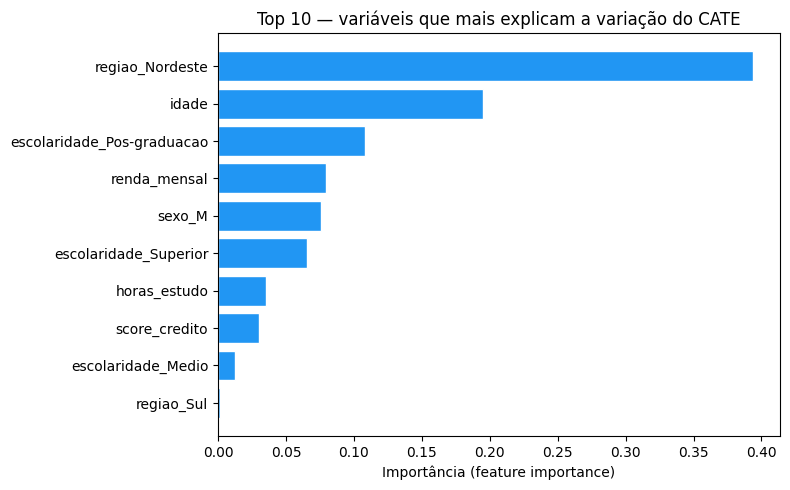

In [41]:
# ── 6. Importância das variáveis para a heterogeneidade ─────────────
# Qual variável mais influencia a variação do efeito?
#
# Abordagem simples: treinar um modelo τ̂ ~ X (regressão do efeito
# estimado nas covariáveis). A feature_importance desse modelo mostra
# quais variáveis mais "explicam" por que o efeito varia entre pessoas.

model_cate = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42)
model_cate.fit(X_all, tau_hat)

# Montar ranking de importância
importancia = pd.DataFrame({
    "variavel": feature_cols,
    "importancia": model_cate.feature_importances_
}).sort_values("importancia", ascending=False)

print("\n" + "=" * 65)
print("Variáveis que mais explicam a heterogeneidade do efeito")
print("=" * 65)
print(importancia.round(4).to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(8, 5))
top = importancia.head(10).sort_values("importancia")
ax.barh(top["variavel"], top["importancia"], color="#2196F3", edgecolor="white")
ax.set_title("Top 10 — variáveis que mais explicam a variação do CATE")
ax.set_xlabel("Importância (feature importance)")
plt.tight_layout()
plt.show()